### **Imoprting Libraries**

In [ ]:
import  torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

### **Defining the device**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### **Data into Train and Val**

In [ ]:
BATCH_SIZE = 128
data_transform = transforms.Compose(
    [
        transforms.ToTensor(),
    ]
)

In [ ]:
train_dataset = datasets.MNIST(root = "./data", train = True,   transform = data_transform, download = True)

###**Making the Data Loader**

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle = True)

### **Part 1: Auto Encoder class**

In [ ]:
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim = 32, hidden_dim = 256):
        super().__init__()

        # Encoder
        self.encoder =  nn.Sequential(
            nn.Linear(784, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon


In [ ]:
model = AutoEncoder().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 1e-3)


In [ ]:
epochs = 5
model.train()
for epoch in range(epochs):
    total_loss = 0
    for x , _ in train_loader:
        x = x.view(-1, 784).to(device) # Flatten each 28x28 image into 784 values
        optimizer.zero_grad()
        x_recon = model(x)
        loss = criterion(x_recon, x)
        loss.backward()
        optimizer.step()
        total_loss = total_loss + loss.item()
        average_loss = total_loss / len(train_loader)

    print(f"Epoch: {epoch+1}, Loss: {average_loss:.6f} ")

Epoch: 1, Loss: 0.043352 
Epoch: 2, Loss: 0.020509 
Epoch: 3, Loss: 0.017075 
Epoch: 4, Loss: 0.015660 
Epoch: 5, Loss: 0.014732 


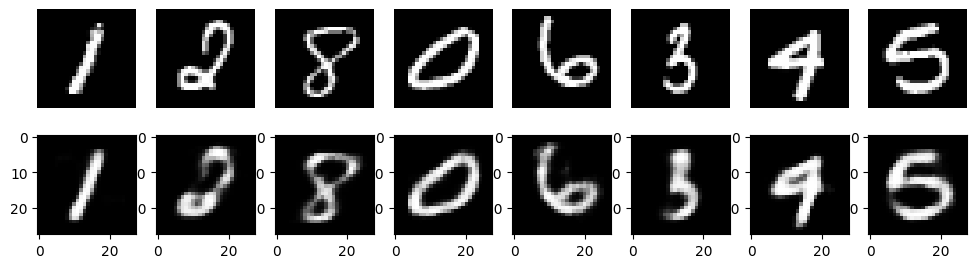

In [ ]:
model.eval()
with torch.no_grad():
    x, _ = next(iter(train_loader))
    x = x.view(-1, 784).to(device)

    x_recon = model(x)
    n = 8
    plt.figure(figsize = (12,3))
    for i in range(n):
        plt.subplot(2, n, i+1)
        plt.imshow(x[i].view(28, 28), cmap = "gray")
        plt.axis("off")
        plt.subplot(2, n, i+1+n)
        plt.imshow(x_recon[i].view(28,28), cmap = "gray")
    plt.show()